# Libs

In [99]:
import pyvisa
import matplotlib.pyplot as plt
import numpy as np
import time

# Code

## INTRO

In [2]:
rm = pyvisa.ResourceManager('C:/windows/System32/visa64.dll')

for r in rm.list_resources():
    print(f"{r=}")
    # if 'USB' in r:
    #     print('Connecting over USB')
    #     rig = rm.open_resource(r)
    #     break

r='USB0::0x1AB1::0x04CE::DS1ZA221403528::INSTR'


In [3]:
osc_rig = rm.open_resource('USB0::0x1AB1::0x04CE::DS1ZA221403528::INSTR')

In [ ]:
# [1], `./README.md`
osc_rig.timeout = 1500 # [ms]
osc_rig.chunk_size = 32 
max_points = 250_000

In [6]:
print(max_points)

250000


In [13]:
print('device:', osc_rig.query('*IDN?'))

device: RIGOL TECHNOLOGIES,DS1054Z,DS1ZA221403528,00.04.04.SP4



In [ ]:
# Run the oscilloscope = Manually Press the `RUN/STOP` button on the oscilloscope to run
osc_rig.write(':RUN')

6

In [ ]:
# Stop the oscilloscope = Manually Press the `RUN/STOP` button on the oscilloscope to stop
osc_rig.write(':STOP')

7

## EX 1

- 1. read out signal on CH1. Follow the reference [1] `./README.md` + `MSO1000Z/DS1000Z Programming Guide` - Chapter 2 Command System - :WAVE:DATA? - page (2-219)

### Example 1 (read the internal memory waveform data at one time)

In [14]:

print('query the channel of which the waveform data will be read: ', osc_rig.query(':WAVeform:SOURce?'))

query the channel of which the waveform data will be read:  CHAN1



**NOTE:**

- 1. `MSO1000Z/DS1000Z Programming Guide`

```
:WAVeform:MODE

 NORMal: read the waveform data displayed on the screen. 
 
 MAXimum: read the waveform data displayed on the screen when the instrument is 
in the run state and the waveform data in the internal memory in the stop state.
 
 RAW: read the waveform data in the internal memory. Note that the waveform data 
in the internal memory can only be read when the oscilloscope is in the stop state 
and the oscilloscope cannot be operated during the reading process.
 
 If the MATH channel is selected, only the NORMal mode is valid.

```

- 2. In the reference [1] `./README.md` 

```
The following script assumes that we trigger on CH2 and capture CH1 waveform
```

This means that in `SINGLE MODE`, when the waveform in CH2 meets the trigger set on CH2, the oscilloscope starts to capture the waveforms on both CH2 and CH1, and stop when the specified number of points set for this `SINGLE MODE` are filled in each channel. The example of such trigger setup and capture is in reference [5] `./README.md` (@ 9:48 ) 

In [61]:
# set the waveform mode to RAW to read the data from the internal memory instead
osc_rig.write(':WAV:MODE RAW')

# set the waveform format
osc_rig.write(':WAV:FORM BYTE') 

16

In [85]:
# check the setup
print(f"{osc_rig.query(':WAV:MODE?')=}")
print(f"{osc_rig.query(':WAV:FORM?')=}")

osc_rig.query(':WAV:MODE?')='RAW\n'
osc_rig.query(':WAV:FORM?')='BYTE\n'


In [63]:
print('query the channel of which the waveform data will be read: ', osc_rig.query(':WAVeform:SOURce?'))

# if the source where the data will be collected is not as wanted,
# configure as
osc_rig.write(':WAV:SOUR CHAN1')
print(f"{osc_rig.query(':WAV:SOUR?')}")

query the channel of which the waveform data will be read:  CHAN1

CHAN1



In [50]:
osc_rig.write(':RUN')

6

In [52]:
osc_rig.write(':STOP')

7

To create the situation when **read the internal memory waveform data at one time**:

- 1. as mentioned in `MSO1000Z/DS1000Z Programming Guide` - Chapter 2 Command System - :WAVE:DATA? - page (2-219), 

if the :WAV:FORMAT is set to BYTE (as we did), the :WAV:DATA? could only retrieve maximum 250000 samples (each time this command is called). 

Therefore to make sure we retrieve all the samples in the oscilloscope internal memory at one time calling :WAV:DATA?, we need to set the memory depth of the oscilloscope to be < 250000.

In [51]:
# Manual: the Rigol ds1054 - button `ACQUIRE` - button `Mem Depth`
# The valid memory depth values are
# 6K
# 60K
# 600K
# 6M
# 12M

# IMPORTANT:
# The osc memory depth can only be set/ configured when the osc is in `RUN` state. 
# If the osc is in `STOP` state, we can only query the memory depth
# Query the memory depth of the internal memory osc is possible in both cases.
internal_mem_osc_total_points = 6_000
osc_rig.write(':ACQ:MDEP '+str(internal_mem_osc_total_points))

16

In [64]:
# check the number of samples (or points) a single event sweep on the oscilloscope for a channel are = memory depth
mem = osc_rig.query(':ACQ:MDEP?')
print(f"{mem=}")
mem = int(mem)
print(f"{mem=}")

mem='6000\n'
mem=6000


In [65]:
# check the oscilloscope sampling rate
sampling_rate = osc_rig.query(':ACQ:SRATE?') # samples/second or points/second
print(f"{sampling_rate=}")
sampling_rate = float(sampling_rate)
print(f"{sampling_rate=}")

sampling_rate='1.000000e+03\n'
sampling_rate=1000.0


In [66]:
# reading out from data from the internal memory of channel 1
osc_rig.write(f':WAV:STAR 1')
osc_rig.write(f':WAV:STOP 6000')

16

- 1. `.query_binary_values()` from `pyvisa`: https://pyvisa.readthedocs.io/en/1.8/rvalues.html . 

This relates to `little endian` vs `big endian`. Difference between `little endian` vs `big endian`:

- 2. https://bytebytego.com/guides/big-endian-vs-little-endian/

- 3. The datatype for `.query_binary_values()` from `pyvisa` can be seen at https://docs.python.org/2/library/struct.html#format-characters (which is meantioned in `struct module` in the link in **-1.** (with the help of chatGPT))



In [ ]:
# because we set a sample stored in the oscilloscope internal memory is BYTE, 
# we need to set the datatype in pyvisa accordingly.
# 'B' in pyvisa = unsigned char = 1 BYTE
tmp = osc_rig.query_binary_values(':WAV:DATA?', datatype='B')

In [68]:
print(tmp)

[124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 124, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 122, 122, 122, 122, 122, 122, 122, 122, 122, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 120, 120, 120, 120, 120, 120, 120, 120, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 116, 116, 116, 116, 116, 116, 116, 116, 116, 116, 115, 115, 115, 115, 115, 115, 115, 115, 115, 114, 114, 114, 114, 114, 114, 114, 114, 113, 113, 113, 113, 113, 113, 113, 113, 113, 113, 113, 113, 112, 112, 112, 112, 112, 112, 112, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 110, 110, 110, 110, 110, 110, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 108, 108, 108, 108, 108, 108, 108, 108, 108, 107, 107, 107, 107, 107, 107, 107, 107, 107, 107, 107, 106, 106, 106, 106, 106, 106, 106, 106, 105, 105, 105, 105,

Text(0.5, 0, 'time [s]')

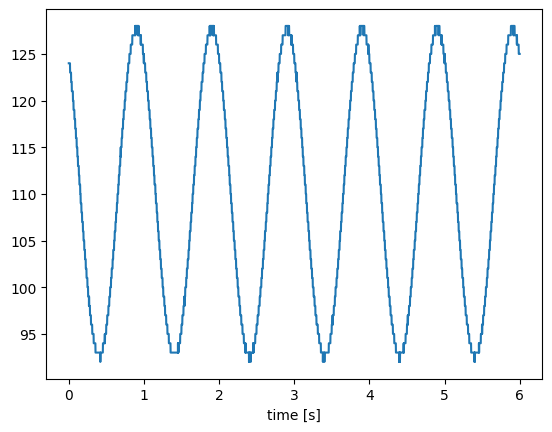

In [ ]:
# convert the x-axis (follow the RAW mode, bcz of the :WAV:MODE configuration above) 
# - see `MSO1000Z/DS1000Z Programming Guide` - Chapter 2 Command System - page (2-216)
x_axis = np.arange(0, len(tmp)) / sampling_rate
plt.plot(x_axis, tmp)
plt.xlabel('time [s]')

To convert the values transfered from the oscilloscope to the right voltage values,
refer to `MSO1000Z/DS1000Z Programming Guide` - Chapter 2 Command System - :WAVE:DATA? - page (2-221)

In [79]:
# queries to convert the values in the y-axis
yorigin = osc_rig.query(':WAV:YORigin?')
print(f"{yorigin=}")
yorigin = int(yorigin)
print(f"{yorigin=}")

yref = osc_rig.query(':WAV:YREFerence?')
print(f"{yref=}")
yref = int(yref)
print(f"{yref=}")

yincr = osc_rig.query(':WAV:YINCrement?')
print(f"{yincr=}")
yincr = float(yincr)
print(f"{yincr=}")


yorigin='17\n'
yorigin=17
yref='92\n'
yref=92
yincr='2.755859e-02\n'
yincr=0.02755859


Text(0, 0.5, 'voltage [V]')

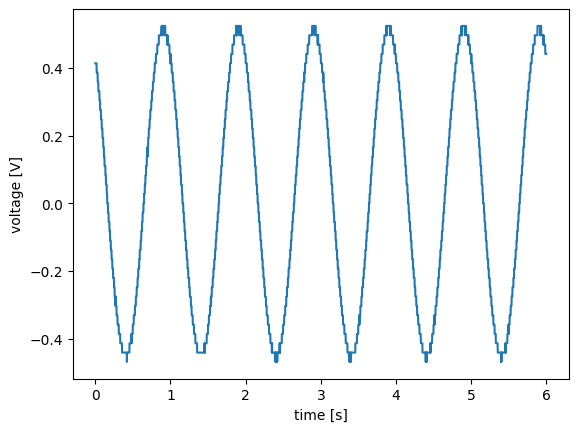

In [83]:
tmp_np = np.array(tmp) 
convert_y_axis = (tmp_np - yorigin - yref)*yincr
plt.plot(x_axis, convert_y_axis)
plt.xlabel('time [s]')
plt.ylabel('voltage [V]')

### Example 2 (read the internal memory waveform data in several batches):

**REFERENCE**

- 1. `MSO1000Z/DS1000Z Programming Guide` - Chapter 2 Command System - :WAVE:DATA? - page (2-219)

- 2. `./README.md`- [1]

In [86]:
# configure the way to store the retrieve the oscilloscope data
# set the waveform mode to RAW to read the data from the internal memory instead
osc_rig.write(':WAV:MODE RAW')

# set the waveform format
osc_rig.write(':WAV:FORM BYTE') 

# check the setup
print(f"{osc_rig.query(':WAV:MODE?')=}")
print(f"{osc_rig.query(':WAV:FORM?')=}")

osc_rig.query(':WAV:MODE?')='RAW\n'
osc_rig.query(':WAV:FORM?')='BYTE\n'


In [87]:
# create the situation where the memory depth is > 250000 samples (1 time of reading with :WAV:DATA?)
osc_rig.write(':RUN')

6

In [88]:
# Manual: the Rigol ds1054 - button `ACQUIRE` - button `Mem Depth`
# The valid memory depth values are
# 6K
# 60K
# 600K
# 6M
# 12M

# IMPORTANT:
# The osc memory depth can only be set/ configured when the osc is in `RUN` state. 
# If the osc is in `STOP` state, we can only query the memory depth
# Query the memory depth of the internal memory osc is possible in both cases.
internal_mem_osc_total_points = 6_000_000
osc_rig.write(':ACQ:MDEP '+str(internal_mem_osc_total_points))

19

In [92]:
# check the current internal memory depth
mem_depth = osc_rig.query(':ACQ:MDEP?')
print(f"{mem_depth=}")

mem_depth='6000000\n'


In [93]:
mem_depth = int(mem_depth)
print(f"{mem_depth=}")

mem_depth=6000000


In [94]:
# After setting the memory depth,
# generate some wave form to be recorded in the oscilloscope as example signals before stop the oscilloscope
osc_rig.write(':STOP')

7

In [98]:
# since each time we can not read more than 250000 samples with :WAV:DATA? (because the WAV:FORM BYTE is already set),
# we need to read in batches. To make sure that the next index inside of the internal buffer is surely known, 
# we set the number of sample to be read < 250000 samples. 
# The index in the internal memory oscilloscope starts from 1.
# If there are N points in the memory, the index starts from 1 to N.

# prefer to choose `samples_in_a_batch` is divisible by the available memory depth,
# and < 250000. 
samples_in_a_batch = 100000 
print(mem_depth/samples_in_a_batch)
number_of_batches = int(mem_depth/samples_in_a_batch)
print(f"{number_of_batches=}")

60.0
number_of_batches=60


In [100]:
# set the osc channel to read from
osc_rig.write(':WAV:SOUR CHAN1')
print(f"{osc_rig.query(':WAV:SOUR?')}")

CHAN1



In [ ]:
# `./README.md` - [1]
buf = []
n_retries = 10
for i in range(0, 60):
    start = i*samples_in_a_batch + 1
    stop = start + samples_in_a_batch - 1
    # print(f"{start=}")
    # print(f"{stop=}")
    time.sleep(0.01)
    osc_rig.write(f':WAV:STAR {start}')
    osc_rig.write(f':WAV:STOP {stop}')

    for i_retry in range(0, n_retries):
        try:
            tmp = osc_rig.query_binary_values(':WAV:DATA?', datatype='B')
            break
        except Exception as e:
            print(f"{e=}")

    buf += tmp

In [111]:
print(f"{len(buf)=}")

len(buf)=6000000


In [112]:
# convert values to display the right value 
# and plot

# X-axis conversion
sampling_rate = osc_rig.query(':ACQ:SRATE?') # samples/second or points/second
print(f"{sampling_rate=}")
sampling_rate = float(sampling_rate)
print(f"{sampling_rate=}")

time_axis = np.arange(0, len(buf)) / sampling_rate

# Y-axis conversion
yorigin = osc_rig.query(':WAV:YORigin?')
print(f"{yorigin=}")
yorigin = float(yorigin)
print(f"{yorigin=}")

yref = osc_rig.query(':WAV:YREFerence?')
print(f"{yref=}")
yref = float(yref)
print(f"{yref=}")

yincr = osc_rig.query(':WAV:YINCrement?')
print(f"{yincr=}")
yincr = float(yincr)
print(f"{yincr=}")

np_buf = np.array(buf) 
volt_axis = (np_buf - yorigin - yref)*yincr

sampling_rate='1.000000e+06\n'
sampling_rate=1000000.0
yorigin='17\n'
yorigin=17.0
yref='92\n'
yref=92.0
yincr='2.755859e-02\n'
yincr=0.02755859


c:\Users\20245580\AppData\Local\anaconda3\envs\microcontroller\lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\20245580\AppData\Local\anaconda3\envs\microcontroller\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


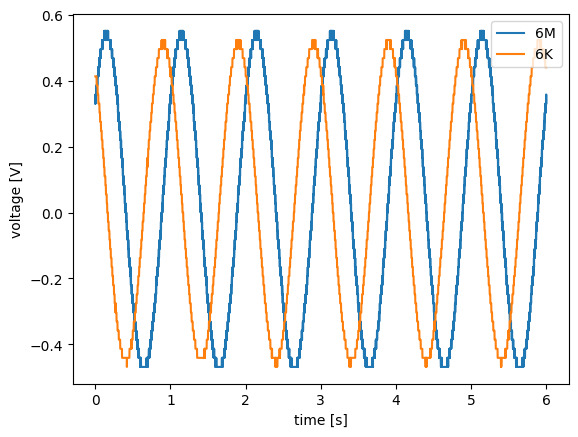

In [113]:
plt.plot(time_axis, volt_axis, label = '6M')
plt.plot(x_axis, convert_y_axis, label = '6K')
plt.xlabel('time [s]')
plt.ylabel('voltage [V]')
plt.legend()

It is clearly seen that 6M samples with 1MHz sampling rate >> (much better) 6K samples with 1KHz

## EX 2

- 1. start trigger on CH2 , capture signal on CH1. Follow the reference [1] `./README.md`

- 2. as advised in `./README.md` - [1], it is much faster to setup trigger manually on the oscilloscope.